# Initial Setup

In [21]:
# Import libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [22]:
# Import dataset
df = pd.read_csv('data_synthetic/dataset.csv')
# View contents
df

,applicant_id,income,loan_amount,term,credit_history,default
0,1a7b9fae-e0da-4e16-976a-b5e8b28646ff,14662,657144,30,1,0
1,7d8ce617-2895-4d5e-b155-7a26a2ae37f7,17636,226200,54,1,1
2,79ef5c77-ca8b-4170-bdf4-1047bc9e08e3,17847,323619,24,0,0
3,f456cdf0-15fa-4c2b-bcb4-d28f415a2322,20556,619547,42,1,1
4,7bfa003a-6716-4a2b-9e65-d3aa21841639,17510,332159,60,1,1
...,...,...,...,...,...,...
1995,42670a17-d130-45d7-a9dc-70721724341d,29378,852745,18,0,1
1996,3a330e2f-e62c-4b1f-9cdc-460f10e09ef6,23980,968074,6,0,1
1997,7ac45afa-0952-4b4c-964b-dc95dae02194,12758,796408,36,1,0
1998,b3a7c7ce-7e35-4955-b56b-b5e2304c0e0c,23237,859989,54,1,1


# Data preparation

In [23]:
# See row and column count
df.shape

(2000, 6)

In [24]:
# We will not be using the ID primary key to train the model, so it is dropped
df = df.drop('applicant_id', axis=1)
df.shape

(2000, 5)

In [25]:
# Check for missing values (Just in case, but there should be none)
df.isna().sum()

income            0
loan_amount       0
term              0
credit_history    0
default           0
dtype: int64

In [26]:
# Count the number of defaulted loans (1) and good loans (0)
df['default'].value_counts()

default
1    1309
0     691
Name: count, dtype: int64

In [27]:
# Summarize the data by default
df.groupby('default').mean()

,income,loan_amount,term,credit_history
default,,,,
0,20145.947902,608378.091172,28.376266,0.693198
1,21375.388846,526856.735676,36.045837,0.392666


# Train-Test Split

In [28]:
y = df.iloc[:,4].values
X = df.iloc[:,0:4].values

In [29]:
X

array([[ 14662, 657144,     30,      1],
       [ 17636, 226200,     54,      1],
       [ 17847, 323619,     24,      0],
       ...,
       [ 12758, 796408,     36,      1],
       [ 23237, 859989,     54,      1],
       [  6608, 544618,     42,      0]], shape=(2000, 4))

In [30]:
y

array([0, 1, 0, ..., 0, 1, 1], shape=(2000,))

In [31]:
# 80% of the code is used for training, the remaining 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [32]:
# Standardize with StandardScaler()
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Risk Model Building

In [33]:
# Use a logistic regression to classify the data
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Performance

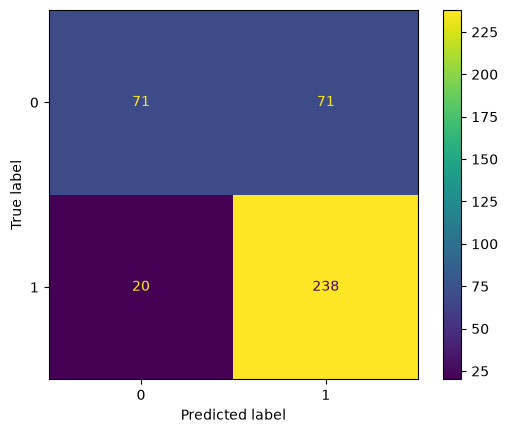

In [34]:
# Print Confusion matrix
# [TrueNegative FalsePositive]
# [FalseNegative TruePositive]
confusion_matrix = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0,1])

display.plot()
plt.show()


In [35]:
print(accuracy_score(y_test, y_pred))

0.7725


# Output File

In [36]:
# Calculating the probability values for default. First column is 0, Second column is 1.
results = model.predict_proba(X_test)
results[:10] # First 10 rows

array([[0.47917879, 0.52082121],
       [0.71976403, 0.28023597],
       [0.37313483, 0.62686517],
       [0.62976816, 0.37023184],
       [0.23211913, 0.76788087],
       [0.06690789, 0.93309211],
       [0.51442455, 0.48557545],
       [0.77347536, 0.22652464],
       [0.13251513, 0.86748487],
       [0.1444449 , 0.8555551 ]])

In [37]:
# Write results to output file
df_prediction_prob = pd.DataFrame(results, columns = ['prob_0', 'prob_1'])
df_prediction_target = pd.DataFrame(model.predict(X_test), columns = ['predicted'])
df_test_data = pd.DataFrame(y_test, columns = ['actual'])

df_combined = pd.concat([df_test_data, df_prediction_prob, df_prediction_target], axis=1)
df_combined

,actual,prob_0,prob_1,predicted
0,1,0.479179,0.520821,1
1,1,0.719764,0.280236,0
2,1,0.373135,0.626865,1
3,0,0.629768,0.370232,0
4,1,0.232119,0.767881,1
...,...,...,...,...
395,1,0.289516,0.710484,1
396,0,0.113932,0.886068,1
397,0,0.461334,0.538666,1
398,1,0.185396,0.814604,1


In [38]:
# Export to csv
df_combined.to_csv("model_results.csv", index=False)